# Cloud Cost Intelligence System for Healthcare Using Python, Data Analytics and Streamlit

## Project Description
This project analyzes cloud infrastructure costs in healthcare environments using data analytics techniques. 
The system identifies cost patterns, detects anomalies, and provides optimization recommendations to help hospitals manage cloud expenses efficiently.

## Introduction

Healthcare systems increasingly rely on cloud computing to manage electronic health records, telemedicine services, medical imaging, and hospital management systems.

While cloud platforms provide scalability and reliability, they also introduce complex cost structures. Hospitals often face difficulties in monitoring cloud usage and controlling infrastructure costs.

This project proposes a Cloud Cost Intelligence System that analyzes simulated hospital cloud usage data to identify cost patterns, detect anomalies, and provide optimization insights.

In [2]:
%pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from datetime import datetime, timedelta

## Dataset Description

This dataset simulates cloud infrastructure usage within a single hospital environment.

The hospital consists of multiple departments such as Radiology, Pharmacy, Patient Records, Telemedicine, Billing, and Emergency services.
Each department uses various cloud services including compute resources, storage, databases, and AI services.

The dataset captures usage metrics and estimated cloud costs for these services.

## Seasonal Variation in Healthcare Cloud Usage

Healthcare cloud resource consumption is not constant throughout the year. 
Certain periods may experience higher usage due to seasonal illnesses, increased hospital visits, or higher demand for telemedicine services.

To simulate realistic cloud usage patterns, seasonal variations are incorporated while generating the dataset. 
This helps represent fluctuations in compute usage, storage consumption, data transfer, and API requests across different time periods.

For example:
- Flu seasons may increase hospital visits and patient record access
- Telemedicine usage may rise during certain months
- Emergency departments may generate unpredictable spikes in cloud activity

Considering these variations helps create a more realistic healthcare cloud usage dataset.

In [4]:

np.random.seed(42)

# Define hospital departments
departments = [
"Radiology","Pharmacy","Patient Records","Telemedicine",
"Billing","Emergency","ICU","Laboratory","Surgery",
"Cardiology","Neurology","Oncology","Pediatrics",
"Administration","Insurance Processing"
]

# Define cloud services
services = [
"Compute","Storage","Database","AI Services",
"Backup","Monitoring","Security","Analytics",
"Image Processing","EHR Systems"
]

# Generate hourly timestamps for the entire year 2025
timestamps = pd.date_range(
    start="2025-01-01 00:00:00",
    end="2025-12-31 23:00:00",
    freq="h"
)

records = len(timestamps)

# Create dataset
data = {
"timestamp": timestamps,
"department": np.random.choice(departments, records),
"service_type": np.random.choice(services, records),
"compute_hours": np.random.uniform(1,24,records),
"storage_usage_gb": np.random.uniform(10,500,records),
"data_transfer_gb": np.random.uniform(5,200,records),
"api_requests": np.random.randint(100,10000,records),
"active_users": np.random.randint(10,500,records),
"cpu_utilization": np.random.uniform(10,95,records)
}

df = pd.DataFrame(data)

# Extract month for seasonal simulation
df["month"] = df["timestamp"].dt.month
#The month column is extracted from the timestamp to allow monthly cloud cost analysis.

# convert api_requests to float for seasonal adjustments
df["api_requests"] = df["api_requests"].astype(float)


# -------------------------------
# Seasonal Healthcare Workloads
# -------------------------------



# Flu Season (Jan–Mar)
df["flu_season"] = df["month"].isin([1, 2, 3])

flu_mask = df["flu_season"] & df["department"].isin(
    ["Telemedicine", "Laboratory", "Patient Records"]
)

df.loc[flu_mask, "compute_hours"] *= np.random.uniform(1.3, 1.6, size=flu_mask.sum())

api_mask = flu_mask & df["department"].isin(["Telemedicine", "Laboratory"])
df.loc[api_mask, "api_requests"] *= np.random.uniform(1.4, 1.7, size=api_mask.sum())


# Viral Season (Jul–Aug)
df["viral_season"] = df["month"].isin([7, 8])

viral_mask = df["viral_season"] & df["department"].isin(["Emergency", "ICU"])

df.loc[viral_mask, "compute_hours"] *= np.random.uniform(1.4, 1.8, size=viral_mask.sum())


# Allergy Season (Sep–Oct)
df["allergy_season"] = df["month"].isin([9, 10])

allergy_mask = df["allergy_season"] & (df["department"] == "Pharmacy")

df.loc[allergy_mask, "api_requests"] *= np.random.uniform(1.2, 1.5, size=allergy_mask.sum())


# Combined seasonal flag (for analysis later)
df["seasonal_effect"] = df[["flu_season", "viral_season", "allergy_season"]].any(axis=1)


# =====================================================
# 2. CONTROLLED ANOMALY INJECTION (IMPORTANT)
# =====================================================

# Select small % of rows as anomalies
anomaly_idx = np.random.choice(df.index, int(0.02 * len(df)), replace=False)

# Split into types
compute_anomaly = anomaly_idx[:len(anomaly_idx)//2]
transfer_anomaly = anomaly_idx[len(anomaly_idx)//2:]

# Compute spike anomaly
df.loc[compute_anomaly, "compute_hours"] *= np.random.uniform(2.5, 3.5, size=len(compute_anomaly))

# Data transfer spike anomaly
df.loc[transfer_anomaly, "data_transfer_gb"] *= np.random.uniform(2.0, 3.0, size=len(transfer_anomaly))


# Optional: tag anomalies (for validation only, not for detection logic)
df["injected_anomaly"] = 0
df.loc[anomaly_idx, "injected_anomaly"] = 1

In [5]:
# -------------------------------
# Cloud Cost Calculation
# -------------------------------

df["compute_cost"] = df["compute_hours"] * 0.6
df["storage_cost"] = df["storage_usage_gb"] * 0.03
df["transfer_cost"] = df["data_transfer_gb"] * 0.05
df["api_cost"] = df["api_requests"] * 0.0001

df["cost"] = (
df["compute_cost"] +
df["storage_cost"] +
df["transfer_cost"] +
df["api_cost"]
)


Cloud service providers typically charge for infrastructure usage in USD. 
In this project, the simulated cloud costs are represented in US Dollars ($) based on resource consumption.

## Dataset Overview

The dataset for this project shows how a hospital would use cloud infrastructure for the whole year 2025. It keeps track of how much resources are used every hour in different hospital departments and cloud services.

Each row in the dataset is a record of cloud usage that shows how much compute resources, storage, network data transfer, API requests, and the estimated cost of these resources in the cloud were used.


To better reflect how healthcare works in the real world, the dataset includes changes in workload that happen at different times of the year. For instance, the flu season makes telemedicine and lab systems busier, and certain infection periods make emergency and ICU workloads busier.

This dataset lets you look at how different hospital departments use cloud services and how those patterns of use affect the overall cost of cloud services.

### Dataset Preview

The preview below shows the first few records of the generated dataset, representing simulated hospital cloud usage logs.

In [6]:
df.head()

,timestamp,department,service_type,compute_hours,storage_usage_gb,data_transfer_gb,api_requests,active_users,cpu_utilization,month,flu_season,viral_season,allergy_season,seasonal_effect,injected_anomaly,compute_cost,storage_cost,transfer_cost,api_cost,cost
0,2025-01-01 00:00:00,ICU,Compute,9.261448,119.609455,74.730982,8992.000000,122,26.581323,1,True,False,False,True,0,5.556869,3.588284,3.736549,0.899200,13.780902
1,2025-01-01 01:00:00,Telemedicine,Database,19.684488,364.544053,95.544436,6122.625387,293,16.738331,1,True,False,False,True,0,11.810693,10.936322,4.777222,0.612263,28.136499
2,2025-01-01 02:00:00,Pediatrics,Backup,2.701153,307.833648,113.225482,4856.000000,95,38.302374,1,True,False,False,True,0,1.620692,9.235009,5.661274,0.485600,17.002576
3,2025-01-01 03:00:00,Insurance Processing,Database,5.024927,255.658011,161.361220,2007.000000,111,37.685885,1,True,False,False,True,0,3.014956,7.669740,8.068061,0.200700,18.953458
4,2025-01-01 04:00:00,Neurology,AI Services,21.462956,315.770261,46.175494,1236.000000,28,66.532864,1,True,False,False,True,0,12.877773,9.473108,2.308775,0.123600,24.783256


In [7]:
df.columns

Index(['timestamp', 'department', 'service_type', 'compute_hours',
       'storage_usage_gb', 'data_transfer_gb', 'api_requests', 'active_users',
       'cpu_utilization', 'month', 'flu_season', 'viral_season',
       'allergy_season', 'seasonal_effect', 'injected_anomaly', 'compute_cost',
       'storage_cost', 'transfer_cost', 'api_cost', 'cost'],
      dtype='object')

### Dataset Columns

The dataset contains the following columns representing cloud infrastructure usage within a hospital environment:

**timestamp** : Time when the cloud resource usage record was generated

**department** : Hospital department utilizing the cloud service

**service_type** : Type of cloud service being used (Compute, Storage, Database, AI Services, etc.)

**compute_hours** : Number of compute resource hours consumed

**storage_usage_gb** : Amount of storage used in gigabytes

**data_transfer_gb** : Volume of data transferred through the network

**api_requests** : Total number of API requests generated by applications

**active_users** : Number of active users interacting with the system

**cpu_utilization** : Percentage of CPU utilization during the workload

**compute_cost** : Cost associated with compute resource usage

**storage_cost** : Cost associated with storage consumption

**transfer_cost** : Cost associated with network data transfer

**api_cost** : Cost generated by API request usage

**cost** : Total cloud cost calculated as the sum of all individual resource costs

In [8]:
df.shape

(8760, 20)

### Dataset Size

The dataset contains multiple records representing cloud infrastructure usage across hospital departments.

The shape output shows the number of rows (records) and columns (features) present in the dataset.

In [9]:
df["department"].unique()

array(['ICU', 'Telemedicine', 'Pediatrics', 'Insurance Processing',
       'Neurology', 'Laboratory', 'Billing', 'Cardiology',
       'Patient Records', 'Emergency', 'Pharmacy', 'Oncology',
       'Administration', 'Radiology', 'Surgery'], dtype=object)

In [10]:
df["service_type"].unique()

array(['Compute', 'Database', 'Backup', 'AI Services', 'Analytics',
       'Security', 'Storage', 'Monitoring', 'Image Processing',
       'EHR Systems'], dtype=object)

##  Data Preprocessing

### Dataset Structure Information

The `df.info()` function is used to display a concise summary of the dataset. It provides information about the dataset structure including column names, data types, and the number of non-null values in each column.

This step helps verify whether the dataset has the correct data types and ensures that there are no missing values that could affect further analysis.

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   timestamp         8760 non-null   datetime64[ns]
 1   department        8760 non-null   object        
 2   service_type      8760 non-null   object        
 3   compute_hours     8760 non-null   float64       
 4   storage_usage_gb  8760 non-null   float64       
 5   data_transfer_gb  8760 non-null   float64       
 6   api_requests      8760 non-null   float64       
 7   active_users      8760 non-null   int32         
 8   cpu_utilization   8760 non-null   float64       
 9   month             8760 non-null   int32         
 10  flu_season        8760 non-null   bool          
 11  viral_season      8760 non-null   bool          
 12  allergy_season    8760 non-null   bool          
 13  seasonal_effect   8760 non-null   bool          
 14  injected_anomaly  8760 n

### Missing Value Analysis

Missing value analysis was performed to ensure data quality before conducting exploratory data analysis. The result shows that the dataset does not contain any missing values, indicating that the generated healthcare cloud usage dataset is complete and suitable for further analysis.

In [12]:
df.isnull().sum()

timestamp           0
department          0
service_type        0
compute_hours       0
storage_usage_gb    0
data_transfer_gb    0
api_requests        0
active_users        0
cpu_utilization     0
month               0
flu_season          0
viral_season        0
allergy_season      0
seasonal_effect     0
injected_anomaly    0
compute_cost        0
storage_cost        0
transfer_cost       0
api_cost            0
cost                0
dtype: int64

## Statistical Summary of the Dataset

Before performing detailed analysis, it is important to understand the statistical characteristics of the dataset.

The describe() function provides summary statistics for numerical columns including:

- Count of values
- Mean (average)
- Standard deviation
- Minimum and maximum values
- Quartile ranges

This helps in understanding the distribution of cloud resource usage and cost values in the dataset.

In [13]:
df.describe()

,timestamp,compute_hours,storage_usage_gb,data_transfer_gb,api_requests,active_users,cpu_utilization,month,injected_anomaly,compute_cost,storage_cost,transfer_cost,api_cost,cost
count,8760,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,2025-07-02 11:30:00,13.288038,255.646995,103.421572,5129.467877,256.365753,52.967031,6.526027,0.019977,7.972823,7.669410,5.171079,0.512947,21.326258
min,2025-01-01 00:00:00,1.003628,10.023581,5.001080,102.000000,10.000000,10.010961,1.000000,0.000000,0.602177,0.300707,0.250054,0.010200,1.940036
25%,2025-04-02 05:45:00,7.064348,134.284472,53.300358,2597.750000,135.000000,31.742162,4.000000,0.000000,4.238609,4.028534,2.665018,0.259775,16.523867
50%,2025-07-02 11:30:00,12.969211,256.820529,102.906759,5074.000000,259.000000,53.123851,7.000000,0.000000,7.781527,7.704616,5.145338,0.507400,21.194522
75%,2025-10-01 17:15:00,18.917349,375.485640,151.262593,7610.250000,377.250000,74.522589,10.000000,0.000000,11.350410,11.264569,7.563130,0.761025,25.975100
max,2025-12-31 23:00:00,79.607189,499.951479,554.686331,15762.844251,499.000000,94.988231,12.000000,1.000000,47.764313,14.998544,27.734317,1.576284,67.373268
std,NaN,7.817111,140.647667,59.074376,2966.449610,140.647216,24.566988,3.448048,0.139930,4.690267,4.219430,2.953719,0.296645,6.983052


### Observation

The statistical summary provides insights into the distribution of cloud resource usage across hospital departments. 
The mean values indicate the average usage of compute, storage, and data transfer resources, while the standard deviation shows the variability in usage patterns. 
These statistics help identify potential cost-heavy operations within the hospital's cloud infrastructure.

## Saving the Processed Dataset

After generating and analyzing the simulated healthcare cloud usage dataset, it is saved as a CSV file. 

This allows the dataset to be reused for further analysis, visualization, and integration with the Streamlit dashboard application.

In [14]:
1# Save dataset
df.to_csv("data/hospital_cloud_cost_dataset.csv", index=False)

print("Dataset saved to data folder")

Dataset saved to data folder


The final processed dataset is saved as a CSV file for further analysis and integration with the Streamlit dashboard application.

## Exploratory Data Analysis

####  Department Distribution (Cloud Usage by Department)

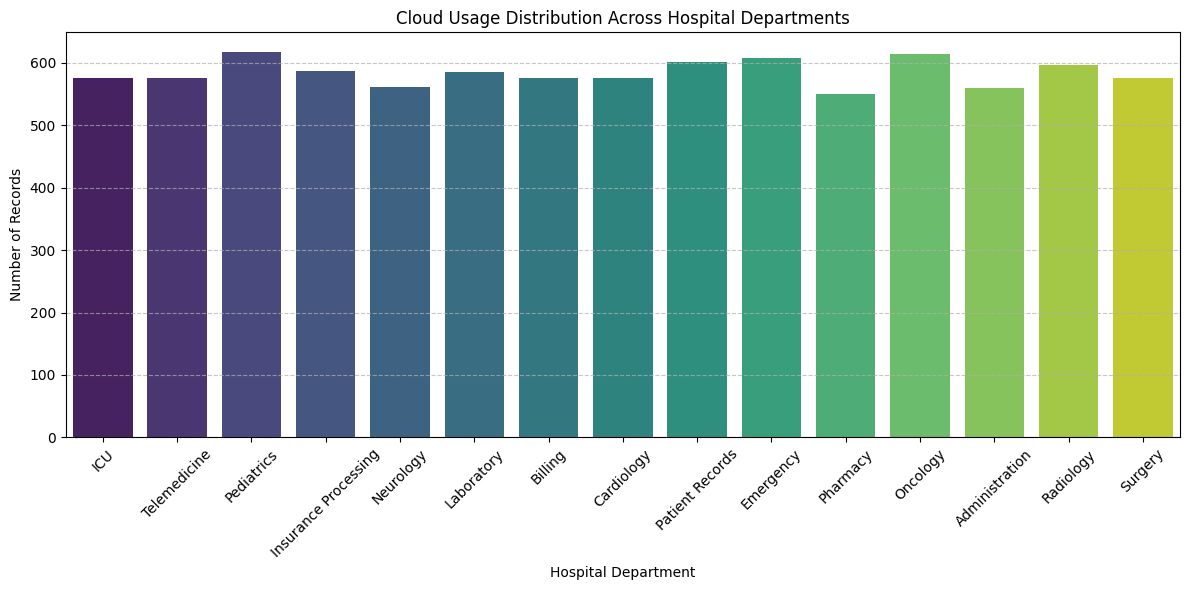

In [15]:
df = pd.read_csv("data/hospital_cloud_cost_dataset.csv")    # read dataset from data folder

plt.figure(figsize=(12,6))

sns.countplot(data=df, x="department", hue="department", palette="viridis", legend=False)

plt.title("Cloud Usage Distribution Across Hospital Departments")
plt.xlabel("Hospital Department")
plt.ylabel("Number of Records")

plt.xticks(rotation=45)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()

#SAVE

plt.savefig("outputs/Cloud_usage_distribution_across_departments.png", dpi=300, bbox_inches='tight')

plt.show()

### Department-wise Cloud Usage Distribution

The above visualization shows the distribution of cloud usage records across different hospital departments. The graph indicates that cloud services are utilized across multiple departments such as ICU, Telemedicine, Pediatrics, Radiology, Laboratory, Emergency, and Patient Records.

Since this dataset is synthetically generated to simulate a hospital environment, the distribution of records across departments appears relatively balanced. This reflects the fact that modern healthcare systems rely on cloud infrastructure across many departments for storing patient records, processing medical data, supporting telemedicine services, and running hospital management systems.

Departments such as ICU, Radiology, and Laboratory typically require higher cloud dependency in real-world scenarios because they handle critical monitoring systems, medical imaging, and diagnostic data processing. This analysis helps in understanding how cloud infrastructure is distributed across hospital operations.

####  Cloud Service Type Distribution

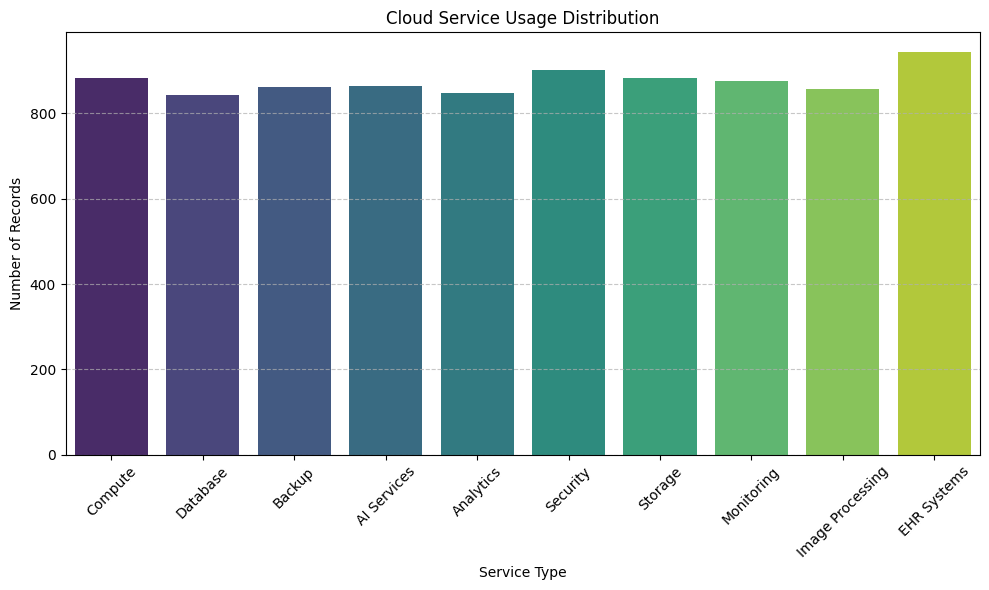

In [16]:
plt.figure(figsize=(10,6))

sns.countplot(data=df, x="service_type", hue="service_type", palette="viridis", legend=False)

plt.title("Cloud Service Usage Distribution")
plt.xlabel("Service Type")
plt.ylabel("Number of Records")

plt.xticks(rotation=45)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()

plt.savefig("outputs/Cloud_service_usage_distribution.png", dpi=300, bbox_inches='tight')

plt.show()

### Cloud Service Usage Distribution

The above visualization illustrates the distribution of different cloud services used within the hospital system. The services include Compute, Database, Backup, AI Services, Analytics, Security, Storage, Monitoring, Image Processing, and EHR Systems.

The graph shows that all cloud services are utilized across the healthcare infrastructure. These services support various hospital operations such as storing patient records, processing medical images, running analytics, and maintaining system security.

Compute services are essential for running hospital applications and processing data, while storage services are used for maintaining electronic health records and medical imaging data. AI services and analytics help in advanced healthcare analysis such as disease prediction and medical diagnostics. Monitoring and security services ensure system reliability and data protection.

This analysis helps understand how different types of cloud services contribute to hospital digital infrastructure and provides a foundation for further cloud cost analysis and optimization.

###  Department-wise Cloud Cost Analysis

This analysis shows the total cloud spending generated by each hospital department. 
It helps identify departments that consume the highest cloud resources.

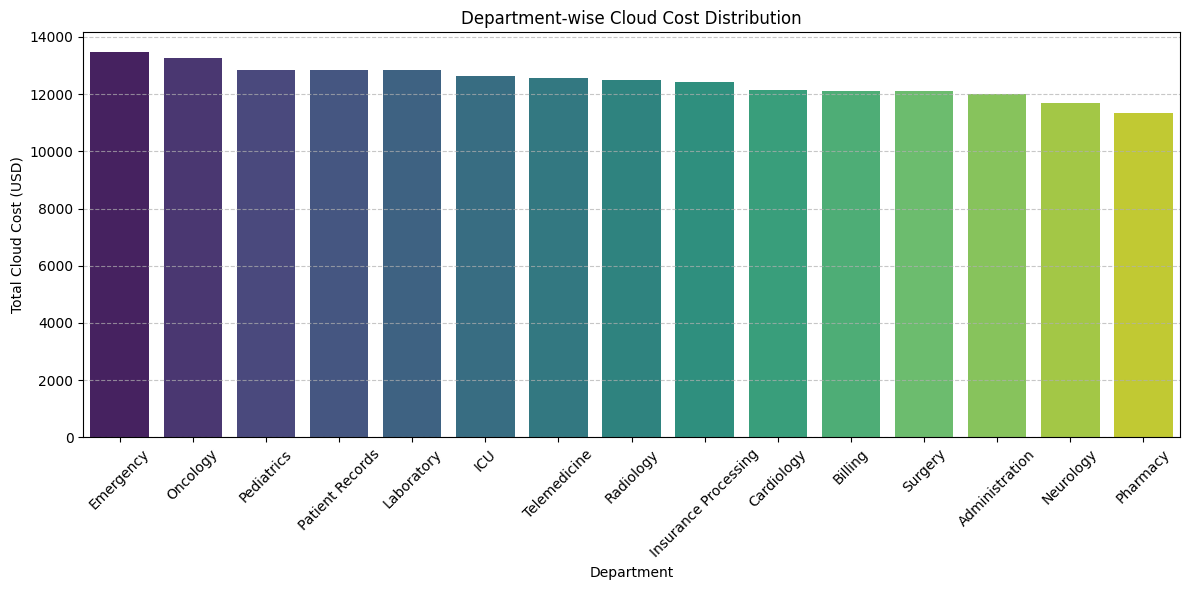

In [17]:
dept_cost = df.groupby("department")["cost"].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))

sns.barplot(x=dept_cost.index, y=dept_cost.values, hue=dept_cost.index, palette="viridis", legend=False)

plt.title("Department-wise Cloud Cost Distribution")
plt.xlabel("Department")
plt.ylabel("Total Cloud Cost (USD)")

plt.xticks(rotation=45)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()

plt.savefig("outputs/Department-wise_cloud_cost_distribution.png", dpi=300, bbox_inches='tight')

plt.show()

### Department-wise Cloud Cost Distribution – Analysis

The above visualization illustrates the total cloud expenditure generated by each hospital department over the simulated time period.

From the graph, it can be observed that certain departments such as Emergency, Oncology, and Pediatrics contribute relatively higher cloud costs compared to other departments. This is expected because these departments typically handle critical medical workloads, real-time monitoring systems, and high volumes of patient data.

Departments like Pharmacy, Administration, and Neurology show comparatively lower cloud costs, which may indicate lower compute intensity or fewer cloud-based applications.

This analysis helps hospital administrators identify departments that consume the most cloud resources and may require optimization strategies such as workload balancing, storage optimization, or compute scaling.

Understanding department-level cost distribution is an important step in implementing an effective Cloud Cost Intelligence system for healthcare infrastructure.

###  Cloud Service Cost Contribution

This visualization shows how different cloud services contribute to the overall cloud expenditure.

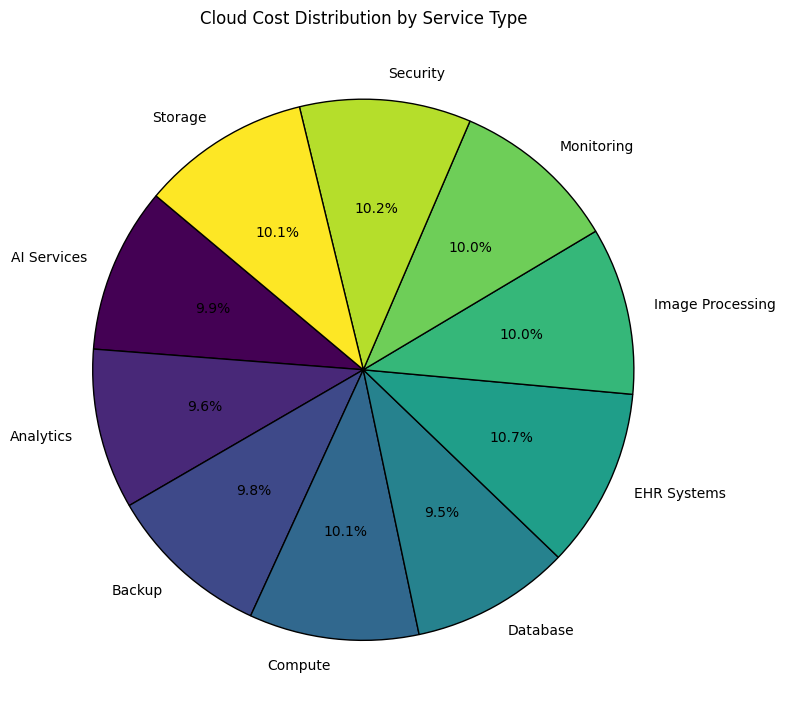

In [18]:
service_cost = df.groupby("service_type")["cost"].sum()

plt.figure(figsize=(8,8))

service_cost.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=140,
    cmap="viridis",
    wedgeprops={"edgecolor":"black"}
)

plt.title("Cloud Cost Distribution by Service Type")

plt.ylabel("")

plt.tight_layout()

plt.savefig("outputs/cloud_cost_distribution_service_type.png", dpi=300, bbox_inches='tight')

plt.show()

### Cloud Cost Distribution by Service Type – Analysis

The above pie chart illustrates how different cloud service categories contribute to the overall cloud expenditure in the hospital infrastructure.

From the visualization, it can be observed that the cloud costs are relatively distributed across multiple service types such as Compute, Storage, Security, Monitoring, Image Processing, and EHR Systems. Services like EHR Systems, Security, and Compute contribute a slightly higher proportion of the total cloud spending.

This distribution indicates that hospital cloud infrastructure relies on a diverse set of services to support critical healthcare operations including electronic health record management, medical image processing, system monitoring, data storage, and analytics.

Understanding service-level cost distribution helps healthcare administrators identify which cloud services generate the highest operational expenses. This insight can support cost optimization strategies such as resource scaling, storage tier optimization, and efficient compute resource allocation.

### Monthly Cloud Cost Trend

This analysis helps identify how cloud spending varies throughout the year and highlights seasonal workload patterns.

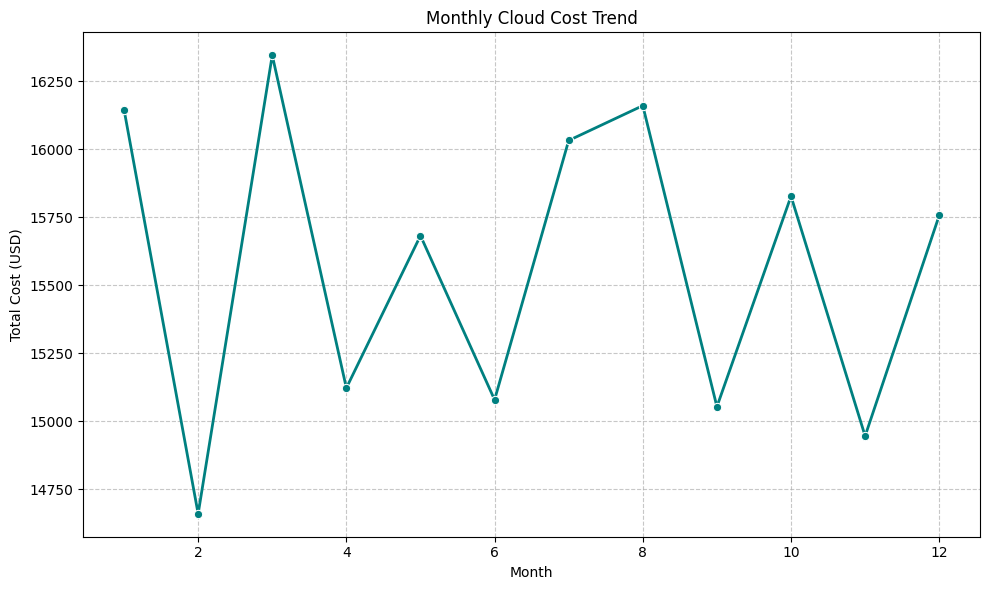

In [19]:
monthly_cost = df.groupby("month")["cost"].sum()

plt.figure(figsize=(10,6))

sns.lineplot(
    x=monthly_cost.index,
    y=monthly_cost.values,
    marker="o",
    color="teal",
    linewidth=2
)

plt.title("Monthly Cloud Cost Trend")
plt.xlabel("Month")
plt.ylabel("Total Cost (USD)")

plt.grid(True, linestyle="--", alpha=0.7)

plt.tight_layout()

plt.savefig("outputs/Monthly_cloud_cost_trend.png", dpi=300, bbox_inches='tight')

plt.show()

### Monthly Cloud Cost Trend – Analysis

The above line graph illustrates the variation in total cloud expenditure across different months of the year. This trend analysis helps identify how cloud resource usage changes over time within the hospital infrastructure.

From the visualization, it can be observed that cloud costs fluctuate throughout the year rather than remaining constant. Certain months show higher cloud spending, which may be associated with increased workload in hospital systems, seasonal healthcare demands, or higher usage of compute and data processing services.

For example, months such as March, July, and August exhibit relatively higher cloud costs compared to other months. These variations may reflect periods of increased patient activity, greater usage of telemedicine services, or higher demand for data processing and analytics systems.

Analyzing monthly cloud cost trends enables hospital administrators to understand seasonal workload patterns and anticipate future cloud expenditure. Such insights are essential for implementing effective cloud cost management and optimization strategies.

### Cloud Cost Component Breakdown

This section analyzes how different cost components such as compute, storage, network transfer, and API requests contribute to total cloud expenditure.

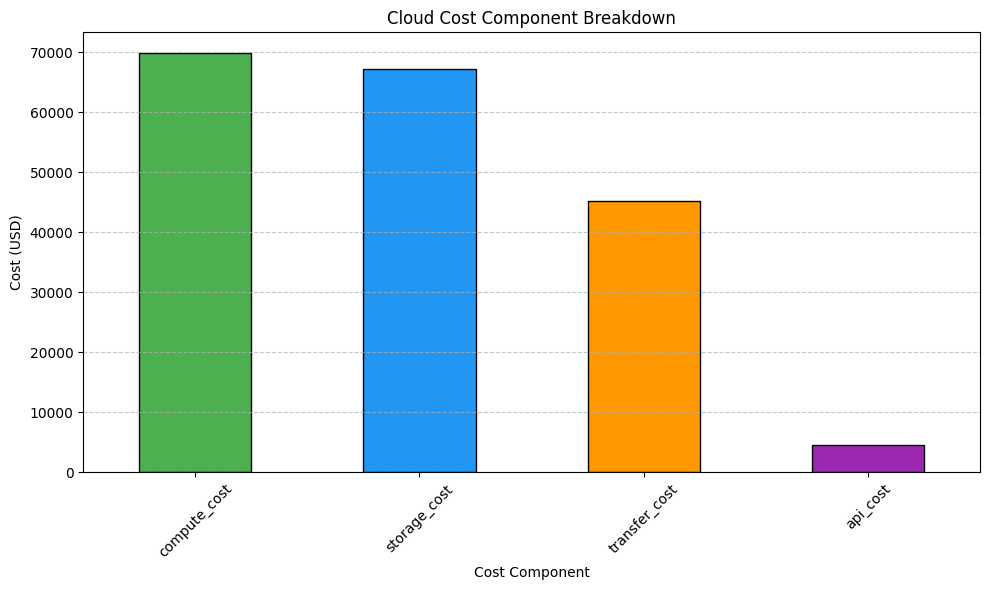

In [20]:
cost_components = df[[
"compute_cost",
"storage_cost",
"transfer_cost",
"api_cost"
]].sum()

plt.figure(figsize=(10,6))

cost_components.plot(
    kind="bar",
    color=["#4CAF50","#2196F3","#FF9800","#9C27B0"],
    edgecolor="black"
)

plt.title("Cloud Cost Component Breakdown")
plt.ylabel("Cost (USD)")
plt.xlabel("Cost Component")

plt.xticks(rotation=45)

plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()

plt.savefig("outputs/Cost_component_breakdown.png", dpi=300, bbox_inches='tight')

plt.show()

### Cloud Cost Component Breakdown – Analysis

The above bar chart illustrates the contribution of different cost components to the overall cloud expenditure of the hospital infrastructure.

From the visualization, it can be observed that compute cost and storage cost represent the largest portions of the total cloud spending. This is expected because healthcare systems heavily rely on compute resources for running medical applications, patient monitoring systems, and analytics workloads, while large volumes of medical data such as imaging records and electronic health records require significant storage capacity.

Data transfer cost contributes a moderate portion of the total cost, reflecting the movement of medical data between systems, departments, and cloud services. In contrast, API request costs represent the smallest portion of the overall expenditure, indicating that although many system interactions occur, their individual cost impact is relatively low.

Analyzing the cost component distribution helps healthcare administrators understand which cloud resources contribute most to operational expenses and enables more effective cloud cost optimization strategies.

###  Department vs Service Cost Heatmap

This heatmap visualizes the cloud cost relationship between hospital departments and cloud service types.

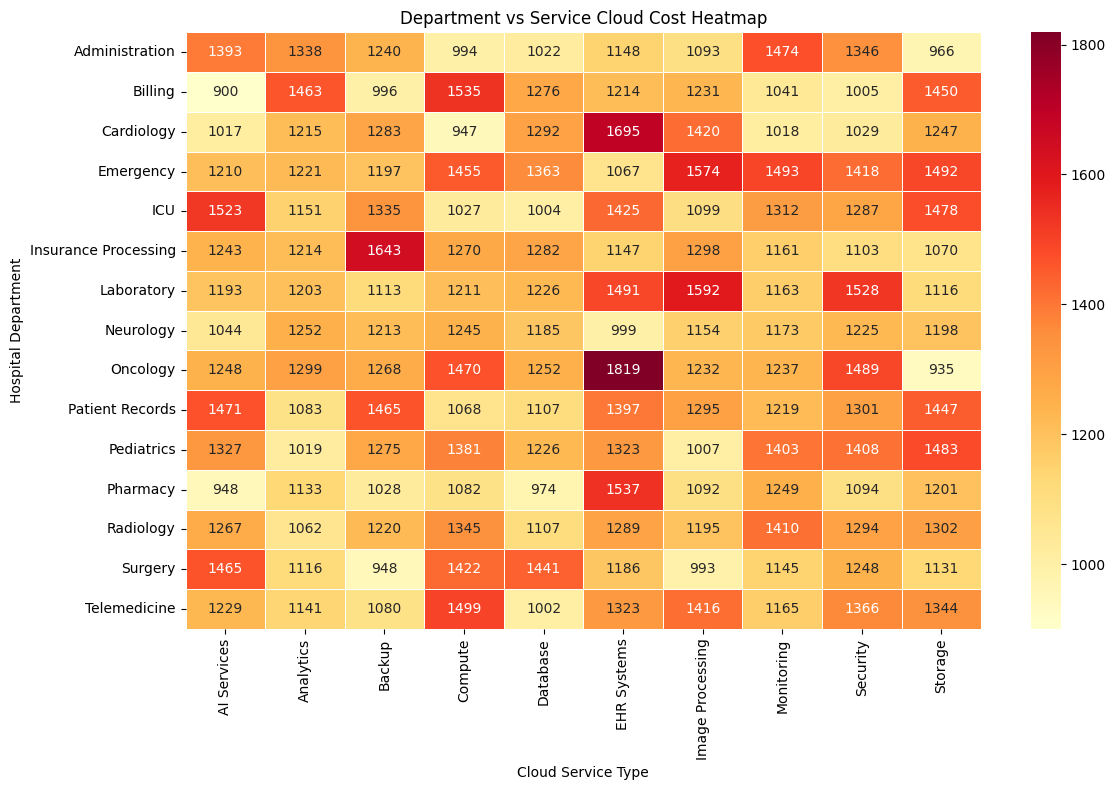

In [21]:
pivot_table = pd.pivot_table(
    df,
    values="cost",
    index="department",
    columns="service_type",
    aggfunc="sum"
)

plt.figure(figsize=(12,8))

sns.heatmap(
    pivot_table,
    cmap="YlOrRd",
    annot=True,
    fmt=".0f",
    linewidths=0.5,
    linecolor="white"
)

plt.title("Department vs Service Cloud Cost Heatmap")
plt.xlabel("Cloud Service Type")
plt.ylabel("Hospital Department")

plt.tight_layout()

plt.savefig("outputs/Department_vs_Service_Cloud_Cost_Heatmap.png", dpi=300, bbox_inches='tight')

plt.show()

### Department vs Service Cloud Cost Heatmap – Analysis

The above heatmap visualizes the relationship between hospital departments and the different cloud services they utilize. Each cell represents the total cloud cost generated by a particular department for a specific cloud service.

Darker color intensities indicate higher cloud expenditure, while lighter shades represent lower cloud costs. This visualization helps identify which departments rely heavily on certain cloud services and where the majority of cloud spending occurs.

For example, departments such as Oncology, Emergency, and ICU tend to show higher usage of compute-intensive services and electronic health record (EHR) systems due to the need for continuous patient monitoring, data processing, and medical record management. Similarly, departments like Radiology and Laboratory may utilize image processing and storage services more extensively due to medical imaging requirements.

This heatmap provides a comprehensive view of how different hospital departments interact with cloud services, enabling better identification of high-cost service areas. Such insights are useful for implementing targeted cloud cost optimization strategies and improving overall cloud resource efficiency within healthcare systems.

###  Cloud Cost Anomaly Detection

Anomaly detection helps identify unusual spikes in cloud spending that may indicate inefficient resource usage or abnormal workloads.

In [22]:
mean_cost = df["cost"].mean()
std_cost = df["cost"].std()

df["anomaly"] = df["cost"] > (mean_cost + 2*std_cost)

anomalies = df[df["anomaly"] == True]

anomalies.head()

,timestamp,department,service_type,compute_hours,storage_usage_gb,data_transfer_gb,api_requests,active_users,cpu_utilization,month,...,viral_season,allergy_season,seasonal_effect,injected_anomaly,compute_cost,storage_cost,transfer_cost,api_cost,cost,anomaly
11,2025-01-01 11:00:00,ICU,Storage,23.968063,406.117127,179.934097,5523.000000,101,42.508707,1,...,False,False,True,0,14.380838,12.183514,8.996705,0.552300,36.113356,True
23,2025-01-01 23:00:00,Laboratory,Analytics,30.218792,424.239604,161.278929,14082.559751,189,65.480048,1,...,False,False,True,0,18.131275,12.727188,8.063946,1.408256,40.330666,True
57,2025-01-03 09:00:00,ICU,AI Services,23.924877,446.733534,151.062538,6488.000000,381,17.904324,1,...,False,False,True,0,14.354926,13.402006,7.553127,0.648800,35.958859,True
85,2025-01-04 13:00:00,Pharmacy,Compute,17.297320,480.834203,193.150419,9062.000000,79,30.579100,1,...,False,False,True,0,10.378392,14.425026,9.657521,0.906200,35.367139,True
107,2025-01-05 11:00:00,Laboratory,Compute,27.101124,456.426141,136.466545,14645.590180,255,43.763038,1,...,False,False,True,0,16.260675,13.692784,6.823327,1.464559,38.241345,True


*Visualization of cost anomaly detection*

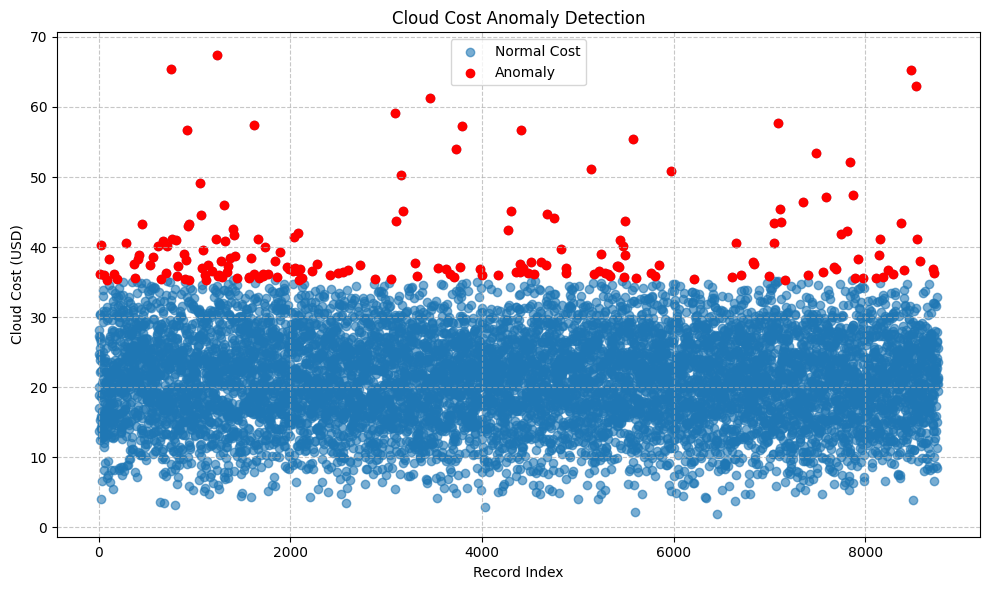

In [23]:
plt.figure(figsize=(10,6))

# Normal data points
plt.scatter(df.index, df["cost"], alpha=0.6, label="Normal Cost")

# Anomalies
plt.scatter(anomalies.index, anomalies["cost"], color="red", label="Anomaly")

plt.title("Cloud Cost Anomaly Detection")
plt.xlabel("Record Index")
plt.ylabel("Cloud Cost (USD)")

plt.legend()

plt.grid(True, linestyle="--", alpha=0.7)

plt.tight_layout()

plt.savefig("outputs/Cloud_Cost_Anomaly_Detection.png", dpi=300, bbox_inches='tight')

plt.show()

### Cloud Cost Anomaly Detection – Analysis

The above scatter plot illustrates the detection of unusual spikes in cloud spending within the hospital cloud infrastructure. Each blue point represents a normal cloud cost record, while the red points highlight anomalous cost values that exceed the expected range.

Anomalies in cloud cost may occur due to sudden increases in resource consumption, unexpected workloads, inefficient system usage, or abnormal application behavior. In healthcare systems, such anomalies may arise from events like increased telemedicine usage, emergency medical activities, large-scale data processing, or unexpected system demands.

Detecting these anomalies is an important component of a Cloud Cost Intelligence system. By identifying abnormal cost spikes, hospital administrators and cloud engineers can investigate the underlying causes, optimize resource allocation, and prevent unnecessary cloud expenditure.

This analysis demonstrates how data analytics techniques can be used to monitor cloud spending patterns and detect unusual cost behaviors in healthcare cloud environments.

## Key Insights from Cloud Cost Analysis

Based on the exploratory data analysis, several important insights can be observed from the simulated healthcare cloud dataset.

• Certain hospital departments generate higher cloud costs due to intensive computational workloads and data processing requirements.

• Cloud spending is distributed across multiple service types such as compute, storage, security, monitoring, and analytics.

• Monthly cost trends indicate fluctuations in cloud expenditure, reflecting variations in workload patterns and seasonal healthcare activities.

• Compute and storage services contribute the largest share of overall cloud costs, highlighting the importance of optimizing these resources.

• Anomaly detection analysis identifies unusual spikes in cloud spending that may indicate inefficient resource usage or unexpected workloads.

These insights demonstrate the importance of monitoring cloud infrastructure usage in healthcare systems to ensure efficient resource allocation and cost control.

## Cloud Cost Optimization Recommendations

Based on the analysis of cloud resource usage patterns, several strategies can be suggested to improve cost efficiency in hospital cloud infrastructure.

• Optimize compute workloads by using auto-scaling and shutting down idle instances.

• Implement tiered storage solutions to move infrequently accessed medical data to lower-cost storage layers.

• Monitor high-cost departments to identify inefficient resource utilization.

• Reduce unnecessary API requests and optimize application interactions.

• Implement cloud monitoring tools to track usage trends and detect abnormal cost spikes early.

These recommendations help healthcare organizations manage their cloud infrastructure more efficiently and reduce operational costs.

## Machine Learning: Cloud Cost Prediction

In this section, a Linear Regression model is used to predict cloud cost based on resource usage such as compute hours, storage usage, data transfer, and API requests.

#### **Step -1 Import necessary libraries**

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

#### **Step -2 Define features and target**

### Feature Selection and Target Variable

In this step, the input features (independent variables) and the target variable (dependent variable) are defined for the machine learning model.

The features include resource usage metrics such as compute hours, storage usage, data transfer, and API requests. These factors influence the cloud cost.

The target variable is the total cloud cost, which the model aims to predict based on the given input features.

In [25]:
X = df[["compute_hours", "storage_usage_gb", "data_transfer_gb", "api_requests"]]
Y = df["cost"]

#### **Step -3 Split the dataset**

### Splitting the Dataset

The dataset is divided into training and testing sets. The training data is used to train the model, while the testing data is used to evaluate the model’s performance on unseen data.

In [26]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

#### **Step -4 Train the model**

### Model Training

In this step, the Linear Regression model is trained using the training dataset. The model learns the relationship between resource usage and cloud cost.

In [27]:
model = LinearRegression()
model.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


#### **Step -5 Make predictions**

In [28]:
Y_pred = model.predict(X_test)

#### **Step -6 Evaluate the model**

### Model Evaluation

The performance of the model is evaluated using evaluation metrics such as Mean Absolute Error (MAE) and R2 Score. These metrics help determine how accurately the model predicts cloud cost.

In [29]:
mae = mean_absolute_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)

print("Mean Absolute Error:", mae)
print("R2 Score:", r2)

Mean Absolute Error: 7.424553108286634e-15
R2 Score: 1.0




The model shows an extremely low Mean Absolute Error and an R2 score of 1.0, indicating near perfect prediction performance.

This is because the dataset is synthetically generated using a predefined cost calculation formula. Therefore, the relationship between input features and the target variable is linear and well-defined, allowing the Linear Regression model to learn it accurately.

### Model Evaluation: Actual vs Predicted Cost

To evaluate the performance of the Linear Regression model, a comparison was made between actual and predicted cloud cost values.

A strong alignment between these values indicates that the model is able to accurately capture the relationship between resource usage and cost.

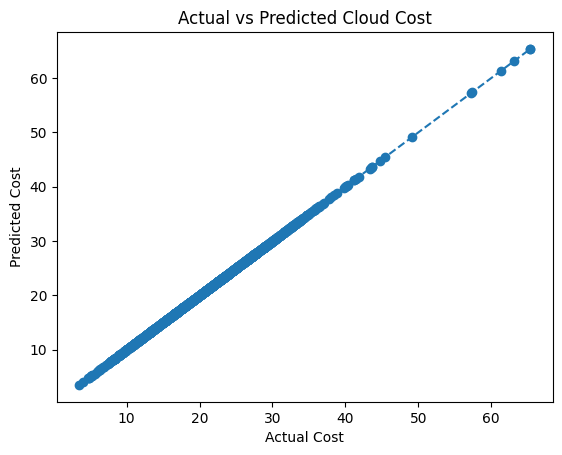

In [30]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(Y_test, Y_pred)
plt.xlabel("Actual Cost")
plt.ylabel("Predicted Cost")
plt.title("Actual vs Predicted Cloud Cost")

# perfect prediction line (reference)
plt.plot([Y_test.min(), Y_test.max()],
         [Y_test.min(), Y_test.max()],
             linestyle='--')

plt.savefig("outputs/actual_vs_predicted.png")
plt.show()

### Insight

The predicted values closely align with the actual cost values, indicating that the model has learned the relationship between resource usage and cost effectively.

This near-perfect alignment is expected here because the dataset is synthetic and follows a strong linear pattern.

### Residual Analysis

Residuals represent the difference between actual and predicted values.

Analyzing residuals helps in understanding how well the model fits the data. Ideally, residuals should be close to zero and randomly distributed.

In this case, the residuals are extremely small, indicating a near-perfect fit. This is expected since the dataset is synthetic and follows a strong linear pattern.

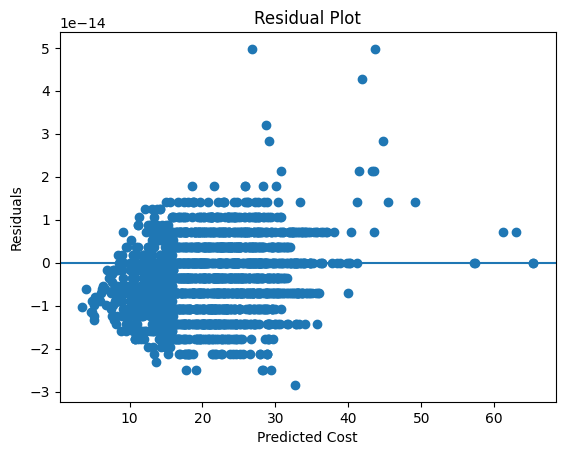

In [31]:
residuals = Y_test - Y_pred

plt.figure()
plt.scatter(Y_pred, residuals)
plt.xlabel("Predicted Cost")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.axhline(y=0)
plt.savefig("outputs/Residual Plot.png")
plt.show()

### Insight

The residuals are extremely close to zero, showing that the difference between actual and predicted values is minimal.

This indicates a near-perfect model fit. However, such behavior is uncommon in real-world datasets, where noise and variability usually exist.

#### **Step -7 Test with custom input**

### Cost Prediction using Custom Input

In this step, the trained model is used to predict cloud cost for a sample input. This demonstrates how the model can estimate cost based on given resource usage values.

In [32]:
sample = pd.DataFrame([[10, 200, 50, 5000]],
                      columns=["compute_hours", "storage_usage_gb", "data_transfer_gb", "api_requests"])

predicted_cost = model.predict(sample)

print("Predicted Cost:", predicted_cost[0])

Predicted Cost: 15.00000000000001


#### **Step -8 Structured anomaly detection**

## Structured Anomaly Detection

In this section, anomaly detection is implemented using a statistical method. Cloud cost values that exceed a defined threshold are identified as anomalies.

The threshold is calculated as:

Threshold = Mean + (2 × Standard Deviation)

This helps in identifying unusual spikes in cloud cost.

In [33]:
mean_cost = df["cost"].mean()
std_cost = df["cost"].std()

threshold = mean_cost + 2 * std_cost

df["anomaly"] = df["cost"] > threshold

print("Total anomalies detected:", df["anomaly"].sum())

Total anomalies detected: 185


Initial anomaly detection was used for visualization during exploratory data analysis. Later, a structured anomaly detection approach was implemented to enable automated detection and integration with the system for further analysis and recommendations.

#### **Step-9 Recommendation Engine**

## Cost Optimization Recommendation Engine

In this section, the system generates cost optimization recommendations based on resource usage patterns and detected anomalies.

The recommendations are rule-based and aim to reduce cloud expenditure by identifying inefficient usage of compute, storage, data transfer, and API calls.

In [34]:
def generate_recommendations(df):

    recommendations = []

    # Department-wise high cost
    dept_cost = df.groupby("department")["cost"].sum()
    high_dept = dept_cost.idxmax()

    recommendations.append(f"{high_dept} department has the highest cloud cost. Consider optimizing its resource usage.")

    # Service-wise high cost
    service_cost = df.groupby("service_type")["cost"].sum()
    high_service = service_cost.idxmax()

    recommendations.append(f"{high_service} service contributes the most to cloud cost. Optimization is recommended.")

    # High data transfer
    high_transfer_dept = df.groupby("department")["data_transfer_gb"].mean().idxmax()
    recommendations.append(f"{high_transfer_dept} shows high data transfer usage. Consider optimizing network usage.")


    anomaly_data = df[df["anomaly"]]

    if len(anomaly_data) > 0:
        top_anomaly_depts = (
            anomaly_data.groupby("department")["cost"]
            .sum()
            .sort_values(ascending=False)
            .head(3)
            .index
        )

        recommendations.append(
            f"Major anomalies detected in departments: {', '.join(top_anomaly_depts)}. Immediate investigation is recommended."
        )

    return recommendations

In [35]:
recs = generate_recommendations(df)

for r in recs:
    print("-", r)

- Emergency department has the highest cloud cost. Consider optimizing its resource usage.
- EHR Systems service contributes the most to cloud cost. Optimization is recommended.
- Oncology shows high data transfer usage. Consider optimizing network usage.
- Major anomalies detected in departments: Laboratory, ICU, Emergency. Immediate investigation is recommended.


### Recommendation Output

The system generates targeted recommendations by identifying high-cost departments, dominant cloud services, abnormal usage patterns, and major anomalies.

Unlike generic suggestions, the recommendations are specific and data-driven, enabling better decision-making for cloud cost optimization in healthcare systems.

### Model Saving

In this step, the trained Linear Regression model is saved using the pickle library.
This allows the model to be reused later without retraining, especially in the Streamlit dashboard for real-time predictions.

In [36]:
import pickle

# Create model folder
os.makedirs("model", exist_ok=True)

# Save model
with open("model/model.pkl", "wb") as f:
    pickle.dump(model, f)

print("Model saved successfully")

Model saved successfully


## Conclusion

In this project, we developed a Cloud Cost Intelligence System for Healthcare to analyze and understand cloud usage patterns effectively. A synthetic dataset was created to simulate real-world healthcare scenarios, including department-wise usage, service-based cost distribution, and seasonal variations such as flu and viral outbreaks.

The analysis helped in identifying key cost drivers, monthly trends, and unusual cost spikes using a rule-based anomaly detection approach. Visualizations such as pie charts, bar graphs, line plots, and scatter plots made it easier to interpret the data and extract meaningful insights.

Overall, the project demonstrates how data analytics can be used to improve visibility into cloud expenses and support better decision-making. The system can be further enhanced by integrating real-world data sources and advanced machine learning techniques for more accurate predictions and optimization.